Extract AE33 zipfiles and save data to parquet files.
Provide plotting functions for data visualization.

joerg.klausen@meteoswiss.ch

In [1]:
import os
import polars as pl
# import pandas as pd
import matplotlib.pyplot as plt
# from io import BytesIO
# import json
# import re
# import tarfile
# import zipfile
from dataprocessor.ae33 import AE33

ae33 = AE33()

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-7fb1hhid because the default path (/prod/zue/fc_development/users/atr/cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


AE33 initialized.


Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/10 ...
Processing ae33-202310021320.zip ...
Processing ae33-202310021300.zip ...
Processing ae33-202310021310.zip ...
Processing ae33-202310021250.zip ...
Processing ae33-202310021240.zip ...
Processing ae33-202310021230.zip ...
Processing ae33-202310021220.zip ...
Processing ae33-202310021210.zip ...
Processing ae33-202310021200.zip ...
Processing ae33-202310021150.zip ...
Processing ae33-202310021130.zip ...
Processing ae33-202310021140.zip ...
Processing ae33-202310021120.zip ...
Processing ae33-202310021110.zip ...
Processing ae33-202310021100.zip ...
Processing ae33-202310021050.zip ...
Processing ae33-202310021040.zip ...
Processing ae33-202310021020.zip ...
Processing ae33-202310021030.zip ...
Processing ae33-202310021010.zip ...
Processing ae33-202310021000.zip ...
Processing ae33-202310020950.zip ...
Processing ae33-202310020940.zip ...
Processing ae33-202310020930.zip ...
Processing ae33-202310020920.z

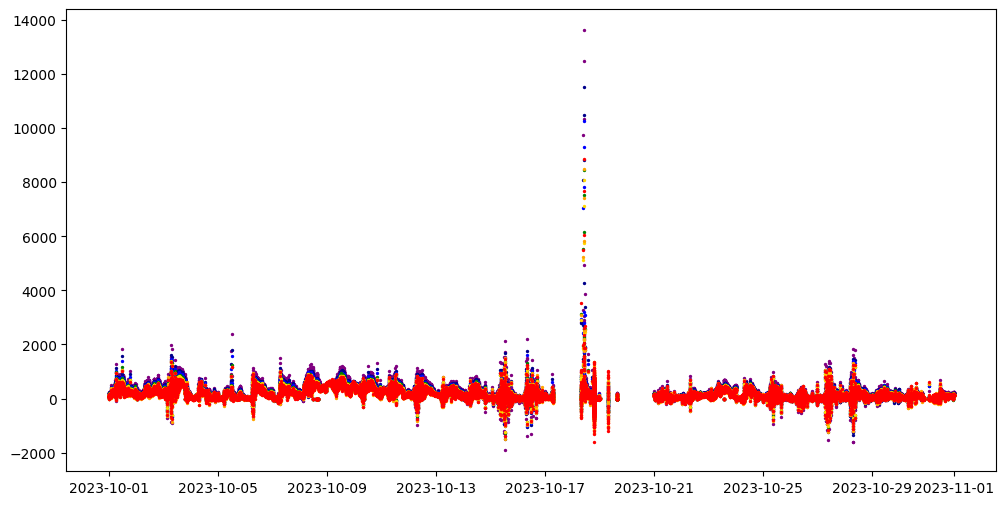

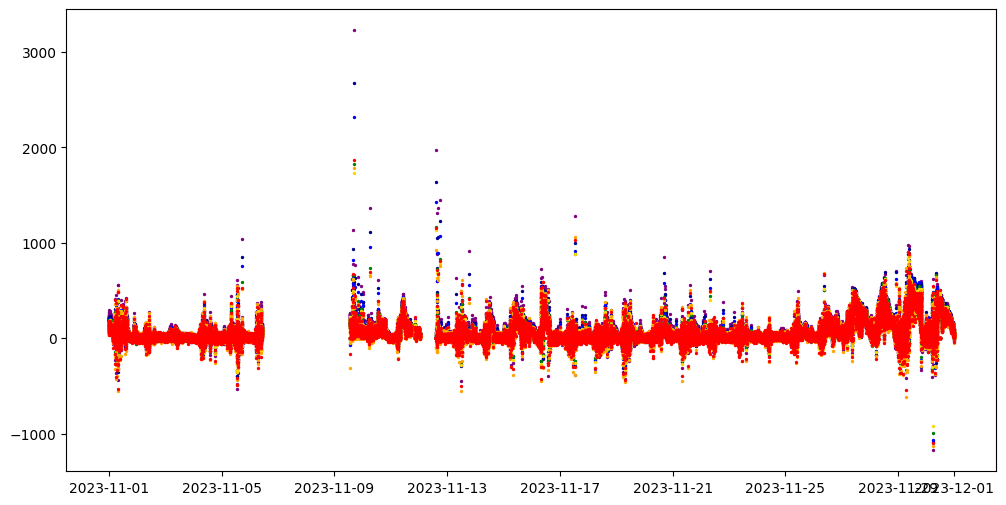

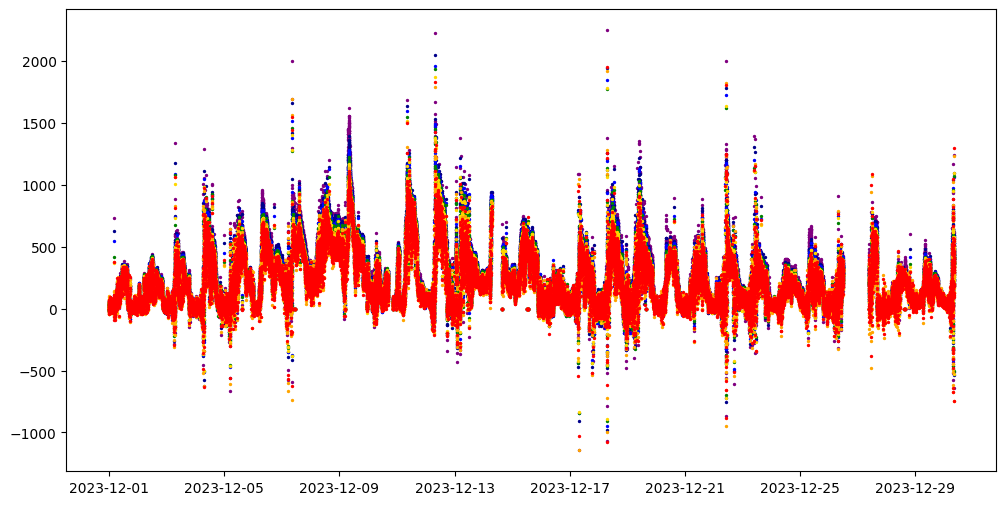

In [4]:
# process AE33 data files
years = ["2023"]
for year in years:
    for month in ['10', '11', '12']:
        source = os.path.join("/product_data/data/pay/Kenya/MKN/incoming/ae33/data", year, month)
        target = os.path.join("results", "ae33", year, month)
        errors = ae33.zipfiles_to_parquet(source=source, target=target)
    print(errors)
print("done")

In [6]:
df = pl.read_parquet("/home/zue/users/jkl/Public/git/gawkenya/results/ae33/2023/ae33.parquet")

In [ ]:
cols = ["DateTime", "BC1", "BC2", "BC3", "BC4", "BC5", "BC6", "BC7"]
display(df.select(cols).describe())

In [7]:

df_flagged = ae33.flag_spurious_data(df)

cols_flags = ["DateTime", "flags_BC1", "flags_BC2", "flags_BC3", "flags_BC4", "flags_BC5", "flags_BC6", "flags_BC7"]
display(df_flagged.select(cols_flags).describe())

describe,DateTime,flags_BC1,flags_BC2,flags_BC3,flags_BC4,flags_BC5,flags_BC6,flags_BC7
str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""456793""",456793.0,456793.0,456793.0,456793.0,456793.0,456793.0,456793.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,0.00194,0.002091,0.00227,0.002211,0.002261,0.001905,0.001931
"""std""",null,0.043998,0.045676,0.047592,0.04697,0.047501,0.0436,0.043899
"""min""","""2022-12-09 00:…",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,null,null,null,null,null,null,null
"""50%""",null,null,null,null,null,null,null,null
"""75%""",null,null,null,null,null,null,null,null
"""max""","""2023-12-27 09:…",1.0,1.0,1.0,1.0,1.0,1.0,1.0


flags_BC1


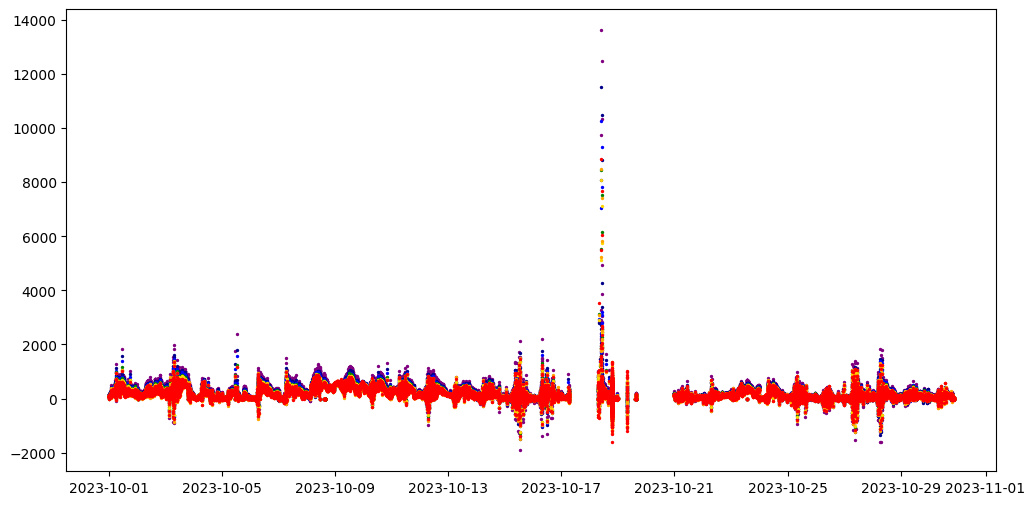

In [4]:
ae33.plot_aethalometer_data(df, start="2023-10-01", end="2023-10-31")

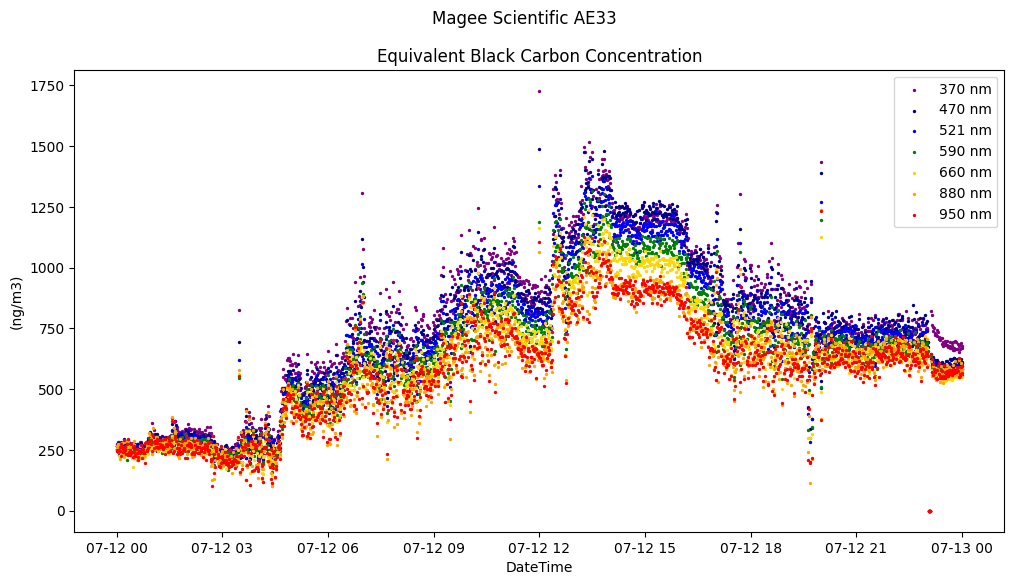

In [9]:
ae33.plot_aethalometer_data(df_flagged, start="2023-07-12", end="2023-07-13")

In [28]:
df_flagged.filter((pl.col("DateTime") >= pl.lit(pl.datetime(2023, 7, 12, 22, 30, 00)))
                    & (pl.col("DateTime") <= pl.lit(pl.datetime(2023, 7, 12, 23, 30, 00)))
                    
                    )

ValueError: could not convert value '2023.dt.datetime([7, 12, 22, 30, 0, 0, Utf8(raise)])' as a Literal

In [ ]:
pl.lipl.Datetime()

In [ ]:
# df["flags_BC1"].describe()

# df, cutoffs = ae33.remove_extremes(df, q=0.00001)
# display(cutoffs)
# Filter the DataFrame to include only rows where 'spurious_flag' is False
# filtered_df = df.filter(df['flags'] == False)

plt.scatter(df_flagged["DateTime"], df_flagged["flags_BC1"])

In [ ]:
# import polars as pl

# def flag_spurious_data(dataframe, value_threshold=0, consecutive_threshold=2):
#     """
#     Flag spurious data in a polars DataFrame consisting of time series data.

#     Parameters:
#     - dataframe: polars DataFrame
#     - value_threshold: threshold for considering values around zero (default: 0)
#     - consecutive_threshold: threshold for consecutive occurrences (default: 2)

#     Returns:
#     - polars DataFrame with an additional 'spurious_flag' column
#     """
#     spurious_flags = []

#     for column in dataframe.columns:
#         # Identify spurious data based on the specified thresholds
#         spurious_mask = (
#             (dataframe[column] <= value_threshold) & 
#             (dataframe[column].shift(-1) > value_threshold) & 
#             (dataframe[column].shift(consecutive_threshold) > value_threshold)
#         ) | (
#             (dataframe[column] <= value_threshold) & 
#             (dataframe[column].shift(1) > value_threshold) & 
#             (dataframe[column].shift(-consecutive_threshold) > value_threshold)
#         )

#         spurious_flags.append(spurious_mask)

#     # Create a new column 'spurious_flag' in the DataFrame
#     dataframe = dataframe.with_column('spurious_flag', pl.col(spurious_flags).any())

#     return dataframe

# # Example usage:
# # Assuming 'your_time_series_data.csv' is your input CSV file
# input_file = 'your_time_series_data.csv'

# # Read the CSV file into a polars DataFrame
# df = pl.read_csv(input_file)

# # Call the function to flag spurious data
# df_with_spurious_flags = flag_spurious_data(df)

# # Display the resulting DataFrame with spurious flags
# print(df_with_spurious_flags)


In [ ]:
# # Concatenate the individual DataFrames into a single one
# combined_data = pl.concat(dataframes)

# # Assuming you have datetime columns, replace 'datetime_column' with the actual column name.
# datetime_column = 'timestamp'

# # Perform aggregation by datetime_column
# agg_data = (
#     combined_data
#     .with_column(combined_data[datetime_column].cast(pl.Date32))
#     .groupby(datetime_column)
#     .agg(pl.sum(combined_data['value_column']))
#     .sort(datetime_column)
# )